Loading data...

--- Training Part A: Baseline Model ---
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9354 - loss: 0.2232 - val_accuracy: 0.9765 - val_loss: 0.0881
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9774 - loss: 0.0745 - val_accuracy: 0.9828 - val_loss: 0.0622
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9840 - loss: 0.0527 - val_accuracy: 0.9817 - val_loss: 0.0644
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9883 - loss: 0.0390 - val_accuracy: 0.9832 - val_loss: 0.0586
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9847 - val_loss: 0.0518

--- Training Part B: Augmented Model ---
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.7853 - loss: 0.6806 - val_accuracy: 0.9575 - val_loss: 0.1613
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9117 - loss: 0.2936 - val_accuracy: 0.9667 - val_loss: 0.113

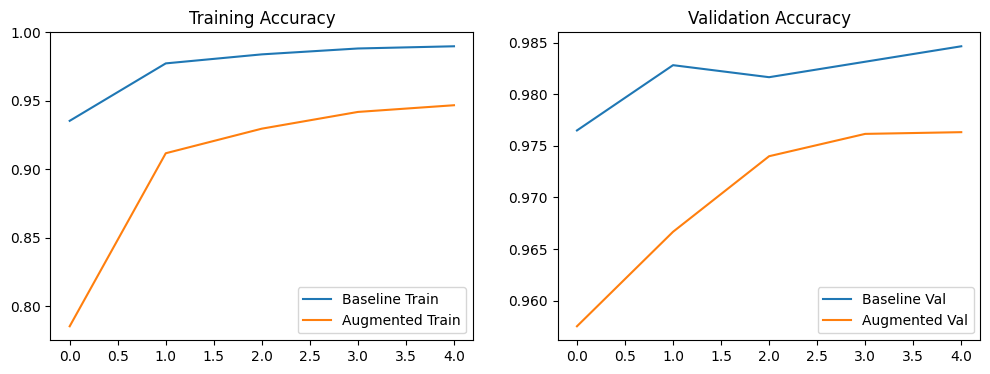

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


print("Loading data...")
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0


print("\n--- Training Part A: Baseline Model ---")

def build_baseline_model():
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_a = build_baseline_model()
history_a = model_a.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)


test_loss_a, test_acc_a = model_a.evaluate(x_test, y_test, verbose=0)



print("\n--- Training Part B: Augmented Model ---")


data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

def build_augmented_model():
    model = models.Sequential([
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_b = build_augmented_model()
history_b = model_b.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)


test_loss_b, test_acc_b = model_b.evaluate(x_test, y_test, verbose=0)



print("\n" + "="*40)
print("ACCURACY REPORT")
print("="*40)
print(f"Part A (Baseline) Test Accuracy:  {test_acc_a:.4f}")
print(f"Part B (Augmented) Test Accuracy: {test_acc_b:.4f}")
print("-" * 40)
print(f"Difference: {test_acc_b - test_acc_a:.4f}")
print("="*40)


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_a.history['accuracy'], label='Baseline Train')
plt.plot(history_b.history['accuracy'], label='Augmented Train')
plt.title('Training Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_a.history['val_accuracy'], label='Baseline Val')
plt.plot(history_b.history['val_accuracy'], label='Augmented Val')
plt.title('Validation Accuracy')
plt.legend()
plt.show()